In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Libraries imported')

Libraries imported


In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.rename(columns={'target':'class'}, inplace=True)
df['class'] = df['class'].apply(lambda i: iris.target_names[i])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


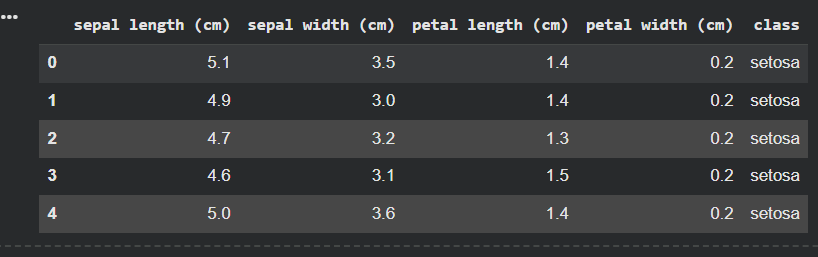

In [3]:
print('Shape:', df.shape)
print('Classes:', df['class'].unique())
df.describe()

Shape: (150, 5)
Classes: [np.str_('setosa') np.str_('versicolor') np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


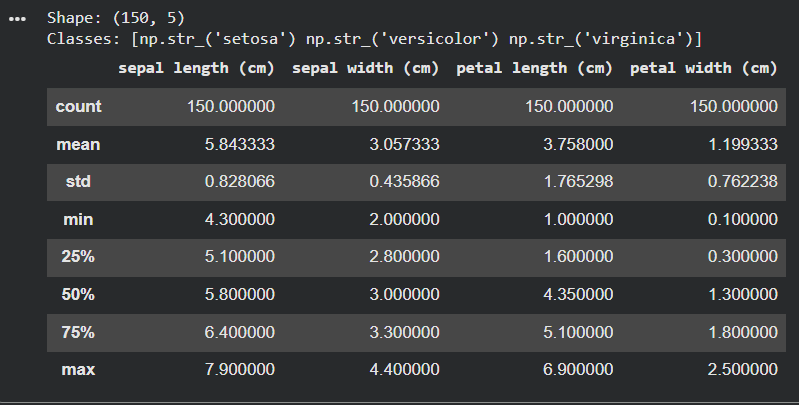

In [4]:
X = df[['petal length (cm)','petal width (cm)']]
y = df['class']
X.head()


,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


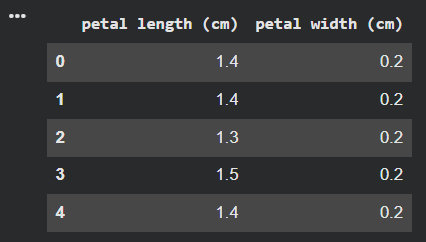

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)


Training size: (105, 2)
Testing size: (45, 2)


In [6]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
print('Model trained')


Model trained


In [7]:
y_pred = svm.predict(X_test)
list(y_pred)[:10]


[np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor')]

In [8]:
y_pred = svm.predict(X_test)
list(y_pred)[:10]


[np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor')]

In [9]:
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
results['Status'] = results.apply(lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1)
results.head(20)

,Actual,Predicted,Status
0,versicolor,versicolor,Correct
1,setosa,setosa,Correct
2,virginica,virginica,Correct
3,versicolor,versicolor,Correct
4,versicolor,versicolor,Correct
5,setosa,setosa,Correct
6,versicolor,versicolor,Correct
7,virginica,virginica,Correct
8,versicolor,versicolor,Correct
9,versicolor,versicolor,Correct


In [10]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



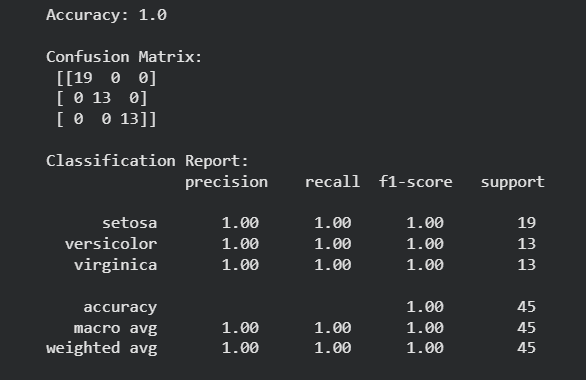

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


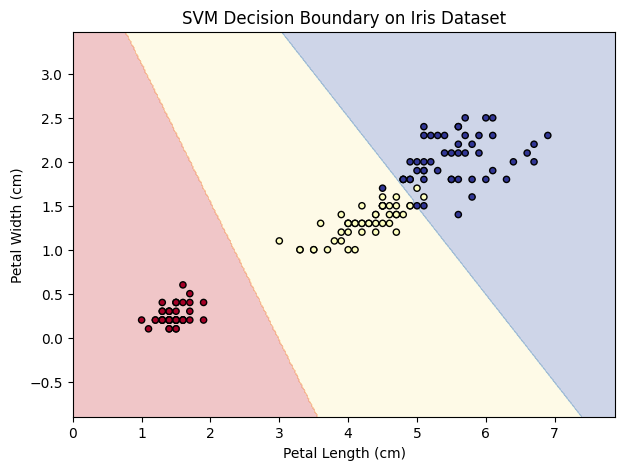

In [14]:
x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
label_to_int = {name: i for i, name in enumerate(iris.target_names)}
Z_numeric = np.array([label_to_int[label] for label in Z.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z_numeric, alpha=0.25, cmap=plt.cm.RdYlBu)
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=[label_to_int[label] for label in y], cmap=plt.cm.RdYlBu, edgecolor='k', s=20)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('SVM Decision Boundary on Iris Dataset')
plt.show()

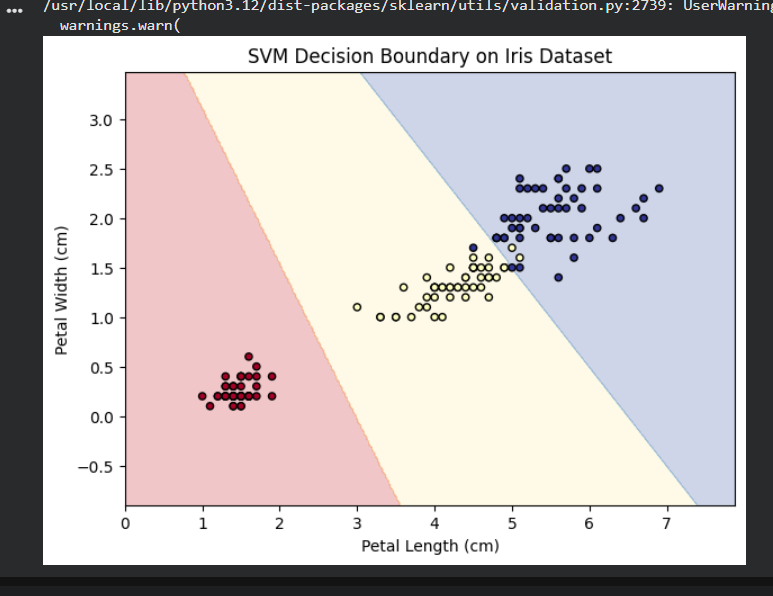